# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [532]:
# Your comment here

# I certify that I did not use AI tools, such as ChatGPT, 
# to generate or write code for this assignment. 
# All work submitted is my own and reflects my understanding of the material.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [533]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [534]:
# Your code here
g = 9.81 # acc of gravity
L = 1.0  # length of the pendulum

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [535]:
# Your code here
def pendulum(t, y):
    theta, omega = y # y[0] = angular position (theta), y[1] = angular velocity (omega)
    dθdt = omega     # derivative of theta with respect to t = angular velocity
    dwdt = -(g/L) * np.sin(theta) # ODE in terms of omega
    return [dθdt, dwdt]

Give you equation some initial conditions. Run the cell below.

In [536]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [537]:
# Your code here
t_span = (0, 10)  # Time range in seconds
t_eval = np.linspace(0, 10, 500) # From 0 to 10s with 500 steps
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval=t_eval) # Solve the differential equation!

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [538]:
# Your code here
theta_values = sol.y[0] # y is a tuple of (theta, omega) and theta is the 0th index value
time_values = sol.t     # t is a separate set of solution and therefore don't need extra index

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [539]:
# Your code here
T_theor = 2 * np.pi * np.sqrt(L / g) # Type in the instructed expression for theoretical period

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [540]:
# Your code here
print(f"Theoretical period of the system is: {T_theor:.1f} s") # Round to two significant digits

Theoretical period of the system is: 2.0 s


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [541]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

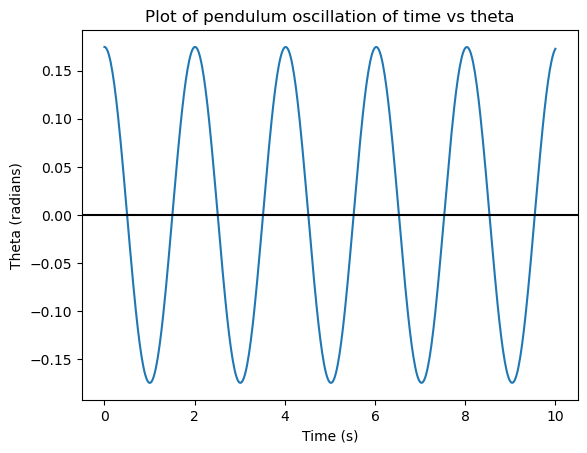

In [542]:
# Your code here
plt.plot(time_values, theta_values)
plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")
plt.title("Plot of pendulum oscillation of time vs theta")
plt.axhline(xmin = 0, color = 'black')
plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [587]:
# Your code here
numerical_period = round(T_numerical, 4)
print(f'The period is: {numerical_period} s.') # Asked question about it, and was really easy in fact

The period is: 2.004 s


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [600]:
# Your comment here
theoretic_period = round(T_theor, 3) # Calculate theoretical period, with 4 sig digits for better comparison
period_difference = theoretic_period-numerical_period

print(f'Theoreticaly approximated period is: {theoretic_period} s.')
print(f'Numerically calculated period is: {numerical_period} s.')
print(f'The approximated period is slightly longer than the calculated period by {period_difference:.3f} s.')
print(f'This is about {round(period_difference/numerical_period*100, 2)} % percentage error.')

Theoreticaly approximated period is: 2.006 s.
Numerically calculated period is: 2.004 s.
The approximated period is slightly longer than the calculated period by 0.002 s.
This is about 0.1 % percentage error.


## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [601]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [602]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"
# Could not downloaded by running the cell, so directly downloaded

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [603]:
# Your code here
df = pd.read_csv("owid-covid-data.csv") # pd.read_csv("csv_name")

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [604]:
# Your code here
df_country = df[df["location"] == "United States"] # Use the same format taught in the lecture to filter rows

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [605]:
df_country = df_country[["date", "total_cases"]]
df_country = df_country.dropna()
# Again, use the same format taught in the lecture to select columns

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [606]:
# Your code here
df_country["days_since_start"] = range(len(df_country)) # Followed the instructions 

Print the first few rows of your `df_country` dataframe.

In [607]:
# Your code here
print(df_country.head(20)) # Could be simply done by using .head() function, printed the first 20 rows

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4
403456  2020-01-10          0.0                 5
403457  2020-01-11          0.0                 6
403458  2020-01-12          0.0                 7
403459  2020-01-13          0.0                 8
403460  2020-01-14          0.0                 9
403461  2020-01-15          0.0                10
403462  2020-01-16          0.0                11
403463  2020-01-17          0.0                12
403464  2020-01-18          0.0                13
403465  2020-01-19          0.0                14
403466  2020-01-20          0.0                15
403467  2020-01-21          0.0                16
403468  2020-01-22          0.0                17
403469  2020-01-23          0.0                18


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [608]:
# Your code here
from scipy.optimize import curve_fit
import numpy as np

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [609]:
# Your code here
def exponential_growth(t, C_0, r):
    return C_0 * np.exp(r * t) # Basic arithmetic using the np.exp() function

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [624]:
# Your code here
days_interest = df_country.head(30)

# Logic: first extract the first 30 rows, and extract the data only in the desired column
days = np.array(days_interest["days_since_start"]) 
cases = np.array(days_interest["total_cases"])

# print(cases)

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [625]:
# Your code here
popt, pcov = curve_fit(exponential_growth, days, cases, p0 = [1, 0.1]) # Use the variables given in the lecture

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [626]:
# Your code here
print(popt) # Check the values of popt, popt is the list of two values: C0 and r
# Assign variable names
C0_fit = popt[0]
r_fit = popt[1]

[0.12389531 0.15384247]


Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [627]:
# Your code here

# Rewrite the variables with corresponding significant digits
C0_fit = round(C0_fit, 2)
r_fit = round(r_fit, 4)

print(f"The value of C0_fit in in two s.f. is: {C0_fit}")
print(f"The value of r_fit in in two s.f. is: {r_fit}")

The value of C0_fit in in two s.f. is: 0.12
The value of r_fit in in two s.f. is: 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [628]:
# Your code here

future_days = np.linspace(0, 60, 61) # use np.linspace(initial, final, bins) function

# print(future_days)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [629]:
# Your code here 

predicted_cases = exponential_growth(future_days, *popt) # Use the format introduced in the lecture

**Scatter** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

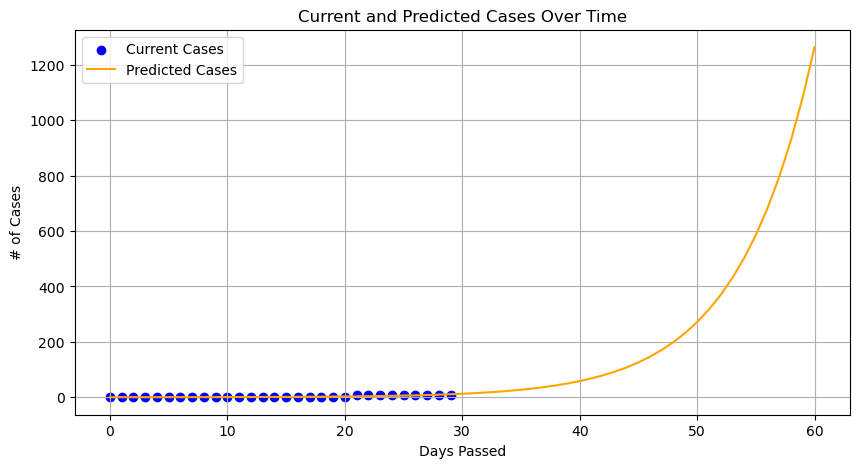

In [630]:
# Your code here

import matplotlib.pyplot as plt

# Create a single figure
plt.figure(figsize=(10, 5))

# Scatter plot for current cases
plt.scatter(days, cases, label="Current Cases", color="blue")

# Line plot for predicted cases
plt.plot(future_days, predicted_cases, label="Predicted Cases", color="orange")

# Labels and title
plt.title("Current and Predicted Cases Over Time")
plt.xlabel("Days Passed")
plt.ylabel("# of Cases")
plt.legend()
plt.grid(True)

# Show the combined plot
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [631]:
# Your comment here

# For a given range of data, it seem to match quite well. 
# Although it seems to match well for the first ~30 days, we cannot tell for such short days of actual cases.
# However, it is still possible for the actual case to exactly follow the model.

Make another plot but this time to **90 days**.

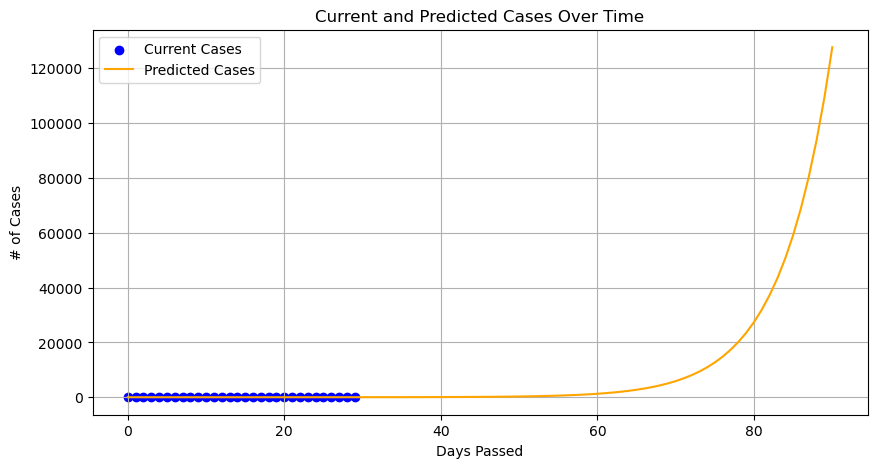

In [632]:
# Your code here
# Do it a similar way as previous: predicted cases
future_days = np.linspace(0, 90, 91)
predicted_cases = exponential_growth(future_days, *popt) # Use the format introduced in the lecture

# Create a single figure
plt.figure(figsize=(10, 5))

# Scatter plot for current cases
plt.scatter(days, cases, label="Current Cases", color="blue")

# Line plot for predicted cases
plt.plot(future_days, predicted_cases, label="Predicted Cases", color="orange")

# Labels and title
plt.title("Current and Predicted Cases Over Time")
plt.xlabel("Days Passed")
plt.ylabel("# of Cases")
plt.legend()
plt.grid(True)

# Show the combined plot
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [640]:
# Your code here

# Index starts from day 0 to day N, so 87th day needs to be addressed with index 87
print(round(predicted_cases[87], 0)) 

80497.0


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [641]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [642]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [643]:
# Load the dataset: tips
df = sns.load_dataset('dowjones')
print(df)

          Date   Price
0   1914-12-01   55.00
1   1915-01-01   56.55
2   1915-02-01   56.00
3   1915-03-01   58.30
4   1915-04-01   66.45
..         ...     ...
644 1968-08-01  883.72
645 1968-09-01  922.80
646 1968-10-01  955.47
647 1968-11-01  964.12
648 1968-12-01  965.39

[649 rows x 2 columns]


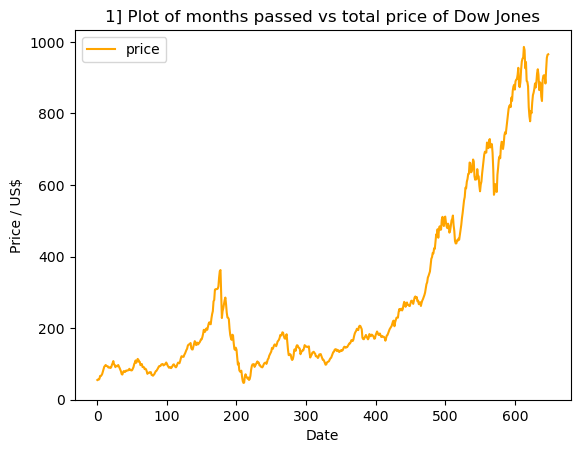

In [644]:
# Make a plot
# To model the plot, will convert dates into numbers as the same way as before
df["months_since_start"] = range(len(df))

# Initialize data
dow_date = df['months_since_start']
dow_price = df['Price']

## Plot of dates passes and price
plt.plot(dow_date, dow_price, c='orange', label='price')
plt.xlabel('Date')
plt.ylabel('Price / US$')
plt.title('1] Plot of months passed vs total price of Dow Jones')
plt.legend()
plt.show()

In [645]:
## Model the plot using exponential growth function, similar to previous but extra factor A
def dow_exp_growth(t, C_0, r, A):
    return A + C_0 * np.exp(r * t)

In [646]:
# Try the fit of C0, r, and A with initial guesses
popt, pcov = curve_fit(dow_exp_growth, dow_date, dow_price, p0=[dow_price.min(), 0.0001, dow_price.min()])

In [647]:
# Check the values of popt and pcov
print(popt)
print(pcov)

[9.02186074e+00 7.25181265e-03 8.13663484e+01]
[[ 1.06627657e+00 -1.87655675e-04 -4.45660026e+00]
 [-1.87655675e-04  3.32971996e-08  7.54966027e-04]
 [-4.45660026e+00  7.54966027e-04  2.83437481e+01]]


In [648]:
# Assign the values of each varibles
C0_fit = popt[0]
r_fit = popt[1]
A_fit = popt[2]
dow_price_fit = dow_exp_growth(dow_date, C0_fit, r_fit, A_fit)

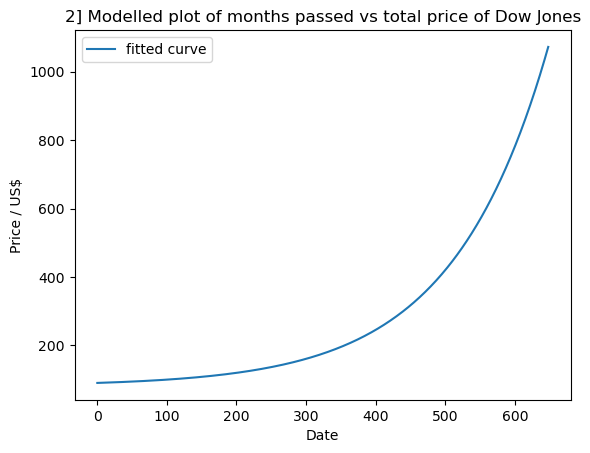

In [649]:
# Make a plot of the modelled function
plt.plot(dow_date, dow_price_fit, label='fitted curve')
plt.xlabel('Date')
plt.ylabel('Price / US$')
plt.title('2] Modelled plot of months passed vs total price of Dow Jones')
plt.legend()
plt.show()

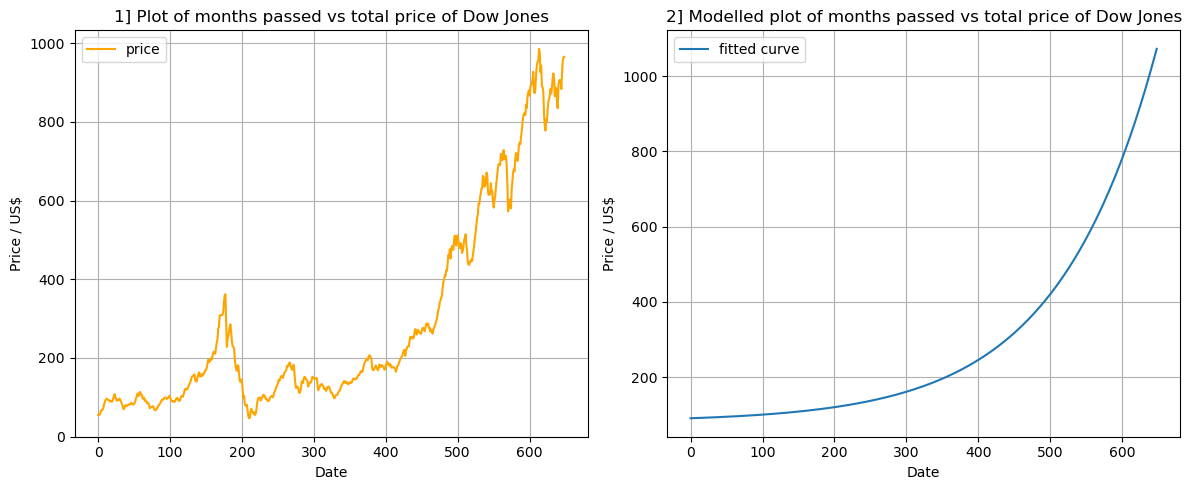

In [651]:
# Your code here
# Compare two plots with subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Make a subplot of 1 row, 2 columns

# First subplot - days vs price
axes[0].plot(dow_date, dow_price, c='orange', label='price')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price / US$')
axes[0].set_title('1] Plot of months passed vs total price of Dow Jones')
axes[0].legend()
axes[0].grid(True)

# Second subplot - days vs modelled cases
axes[1].plot(dow_date, dow_price_fit, label='fitted curve')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price / US$')
axes[1].set_title('2] Modelled plot of months passed vs total price of Dow Jones')
axes[1].legend()
axes[1].grid(True)

# Show the plot
plt.tight_layout()
plt.show()

On it's own branch, submit this notebook to Gradescope! 